## Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv('dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


How does the `Flight Number ` and `Payload` affect the launch outcomes?

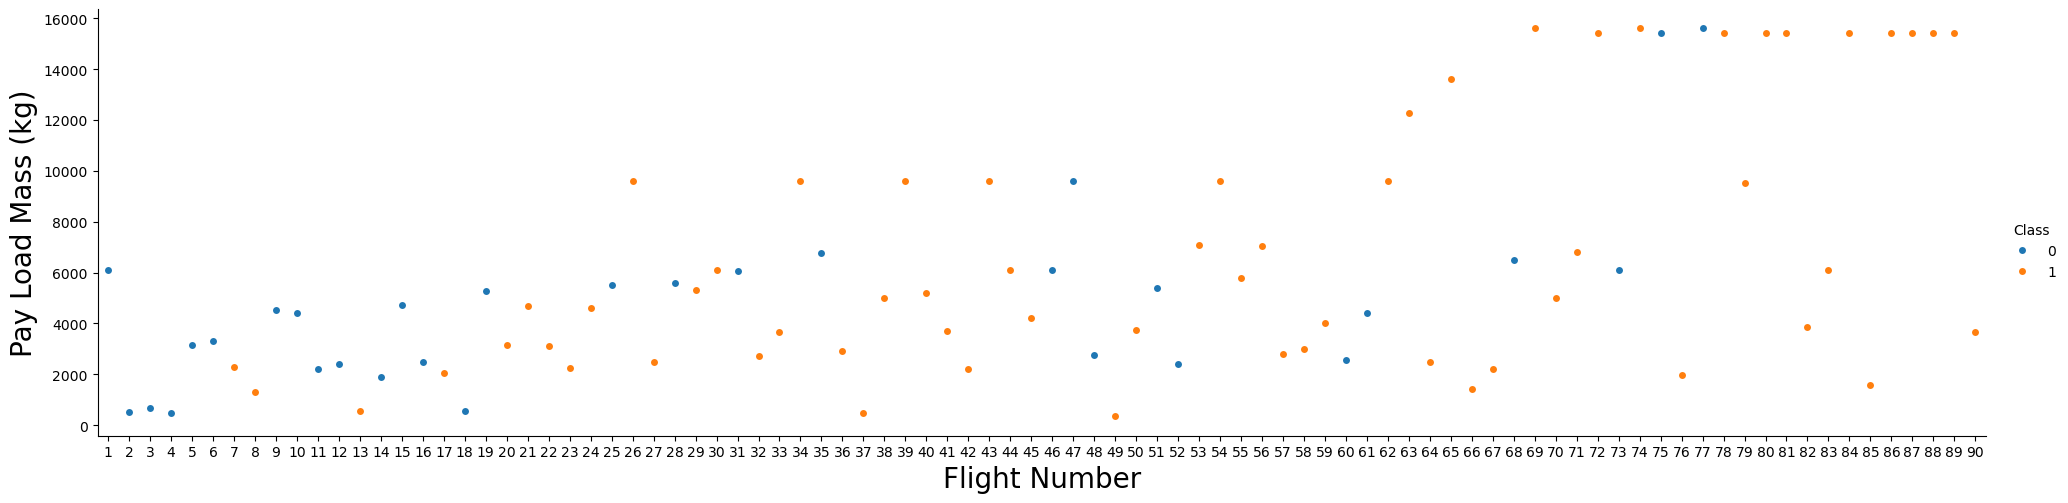

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(y='PayloadMass', x ='FlightNumber', data=df, hue='Class', aspect=4)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay Load Mass (kg)", fontsize=20)
plt.show()

Visualize the realtionship between Flight Number and Launch Site

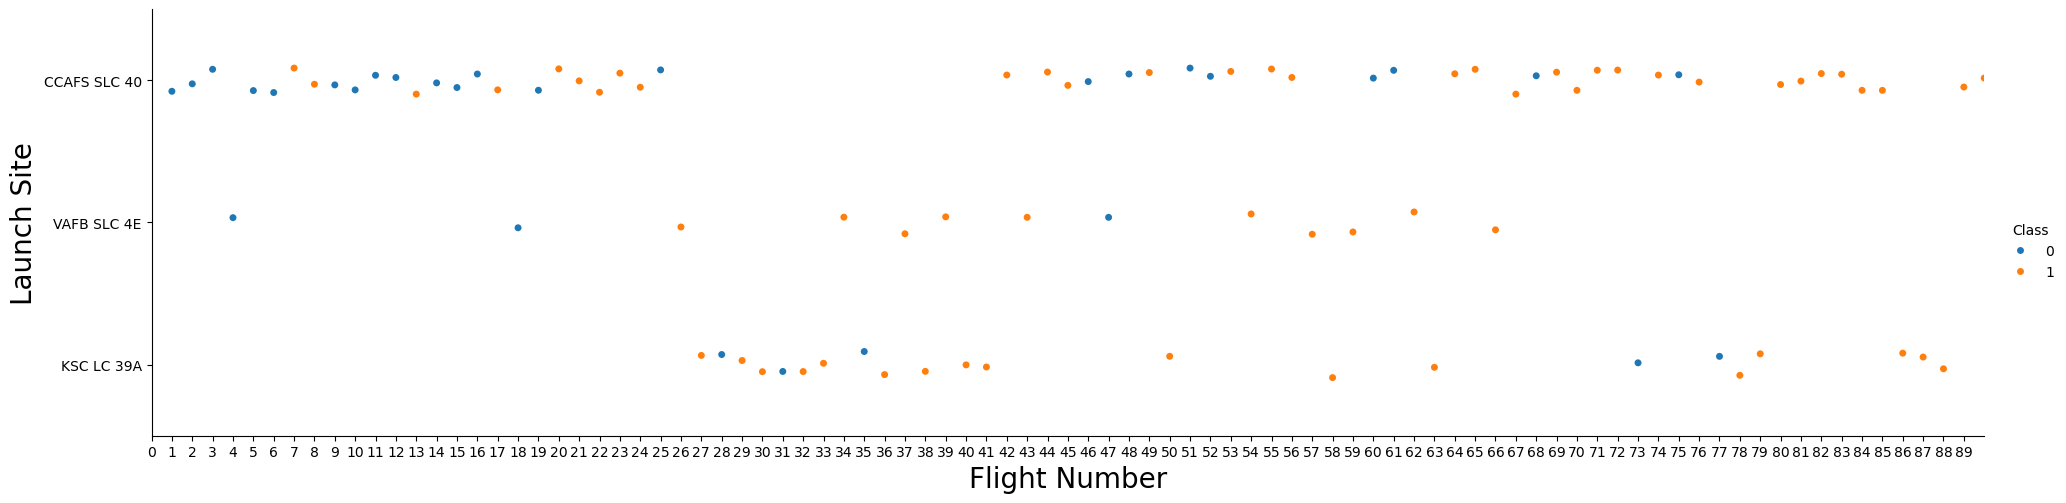

In [4]:
import numpy as np

sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=4)
plt.xticks(np.arange(0, 90))
plt.xlim(0, 90)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

Visually, `CCAFSCLC40` laucnh site has a balanced spread of successful and unsuccessful flights, while `VAFBSLC4E` and `KSCLC39A` show a higher percentage of relative successful flights.

Relationship between Payload Mass and Launch Site

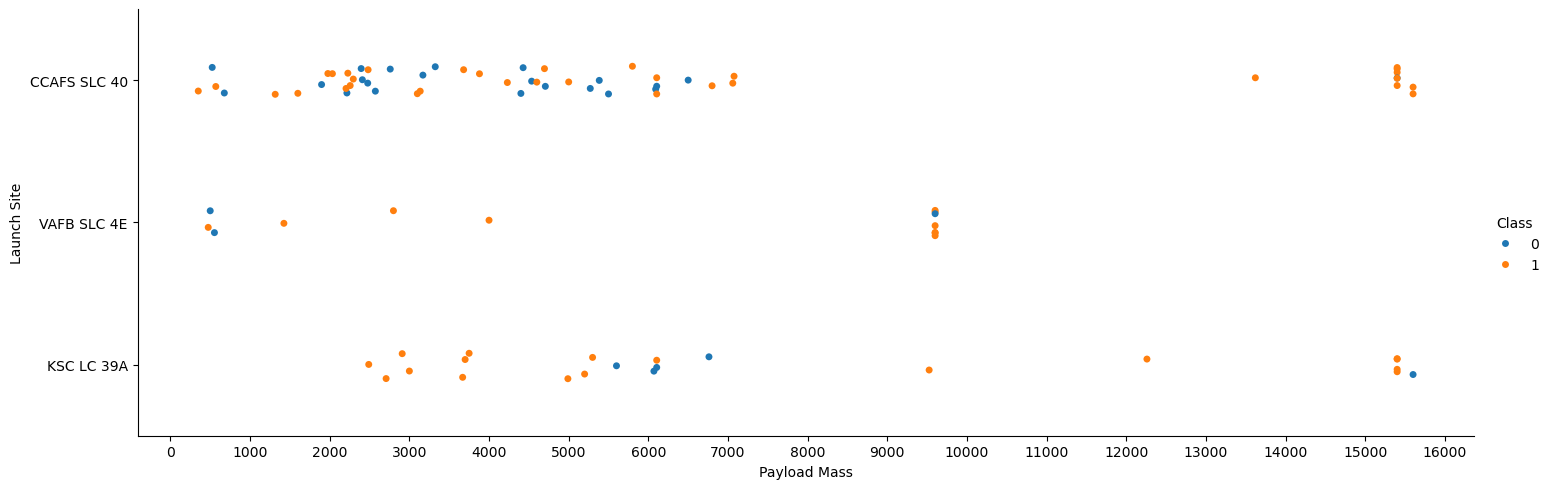

In [5]:
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=3)
plt.xticks(np.arange(0, 16001, step=1000))
plt.xlabel("Payload Mass")
plt.ylabel("Launch Site")
plt.show()

For `VAFBSLC` Launch sites, there are no rockets with payload mass `>` 10000. Also at `KSC-LC-39A`, all rockets lauched with mass less or equal to 5000 were successful.

Visualize the relationship betwwen the success rate of each orbit type

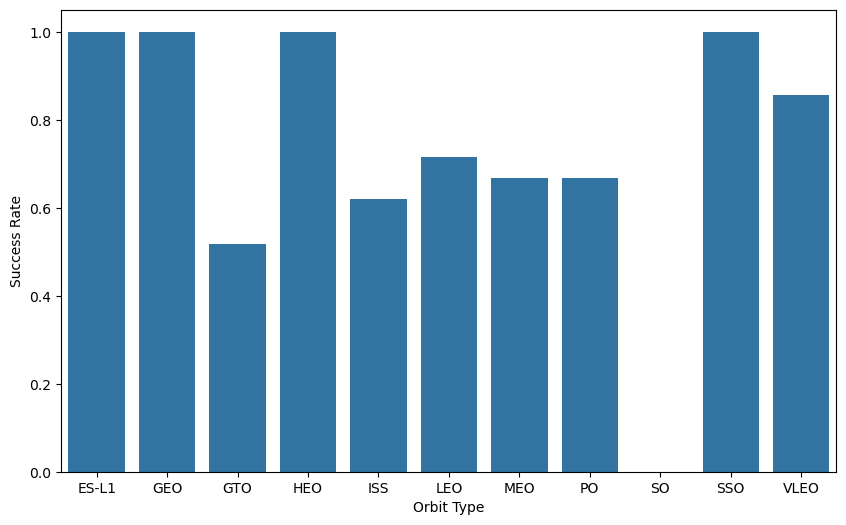

In [10]:
plt.figure(figsize=(10, 6))
orbit = df.groupby("Orbit")['Class'].mean().reset_index()
sns.barplot(x="Orbit", y="Class", data=orbit)
plt.xlabel("Orbit Type")
plt.ylabel("Success Rate")
plt.show()

Rockets at the `ES-L1`, `GEO`, `HEO`, and `SSO` Launch Sites have success rate of 100%. `SO` has a 0% success rate

Visualize the relationship between Flight Number and Orbit Type: For each orbit, I want to see if there is a relationship betwwen Flight Number and the orbit type

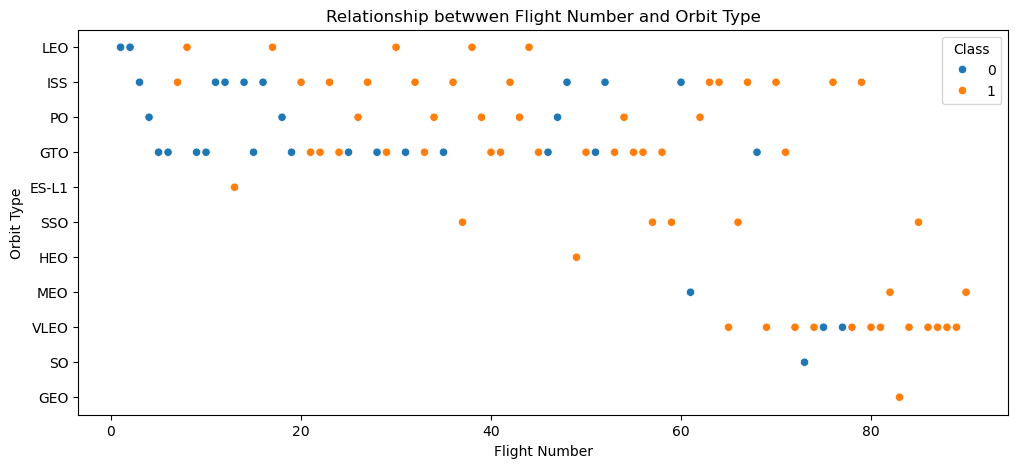

In [14]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x="FlightNumber", y="Orbit", data=df, hue="Class")
plt.xlabel("Flight Number")
plt.ylabel("Orbit Type")
plt.title("Relationship betwwen Flight Number and Orbit Type")
plt.show()

This scatter plot gives more insight to the bar plot above. ES-L1 has a 100% success rate because it has just one flight. The same for SSO (5 flights) GEO, and HEO (1 flight). In the LEO Launch site, success seemes to be related to the number of flights, however, this relationship is not in GTO, ISS, or PO

Visualize the launch success yearly trend

In [15]:
year=[]
def extract_year():
    for i in df['Date']:
        year.append(i.split("-")[0])
    return year

extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


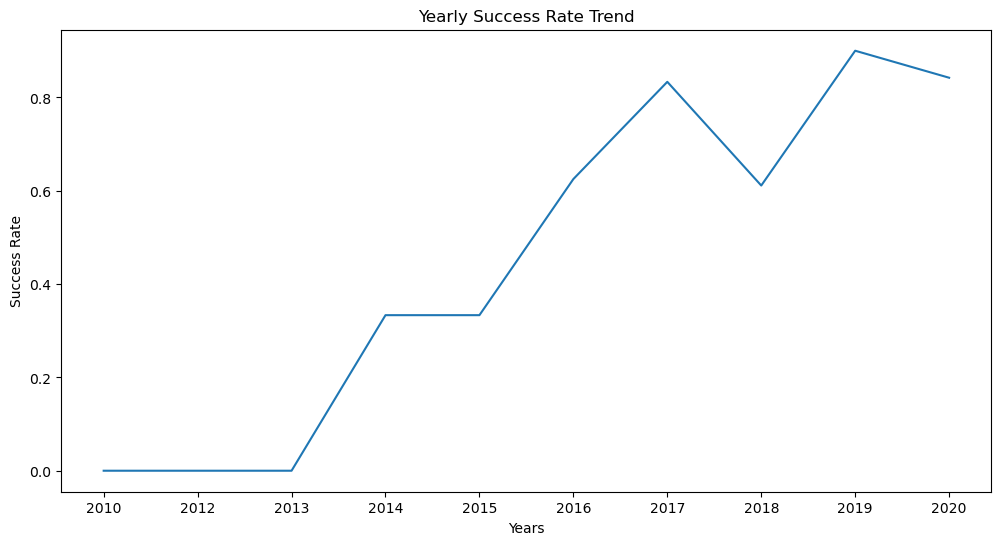

In [17]:
year_df = df.groupby('Date')['Class'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=year_df, x="Date", y="Class")
plt.title("Yearly Success Rate Trend")
plt.xlabel("Years")
plt.ylabel("Success Rate")
plt.show()

From this trend graph, we can see that the average success rate increases each year from 2010-2020, although there was a dip in 2018 and 2020